# Figures Notebook

This notebook mirrors the functions in `visualization.py`.

Suggested workflow:
- Edit `visualization.py` in your editor.
- Rerun the setup cell, or just rerun any source/example cell below.
- Each source/example cell calls `refresh_vis()` so changes in `visualization.py` are reloaded before plotting.
- Once a figure looks right here, move the final parameter or code changes back into `visualization.py`.


In [56]:
%matplotlib inline

from pathlib import Path
import importlib
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import visualization

ROOT = Path.cwd()
DATA_DIR = ROOT / "data" / "260327_eeml"
INSTANCE_DIR = DATA_DIR / "var-chain" / "M10_T500_I10"
TS_PATH = INSTANCE_DIR / "timeseries.npy"
NPZ_PATH = INSTANCE_DIR / "spi_mpis.npz"
RESULTS_MAIN = ROOT / "results" / "sample_efficiency_30seeds_main_results.json"
RESULTS_EDGE = ROOT / "results" / "sample_efficiency_edge_ablation_30seeds_results.json"

for path in [TS_PATH, NPZ_PATH, RESULTS_MAIN, RESULTS_EDGE]:
    assert path.exists(), f"Missing required example asset: {path}"


def refresh_vis():
    global visualization
    visualization = importlib.reload(visualization)
    visualization.apply_style()
    # Notebook-friendly default. Comment this out if you want TeX text rendering.
    plt.rcParams["text.usetex"] = True
    return visualization


vis = refresh_vis()

print(f"Using time series: {TS_PATH}")
print(f"Using MPI matrices: {NPZ_PATH}")
print(f"Using main results: {RESULTS_MAIN}")
print(f"Using edge ablation results: {RESULTS_EDGE}")


Using time series: /Users/wedi0306/Local/OneDrive-Backup/Desktop/2025USYD/eeml-2026-application/data/260327_eeml/var-chain/M10_T500_I10/timeseries.npy
Using MPI matrices: /Users/wedi0306/Local/OneDrive-Backup/Desktop/2025USYD/eeml-2026-application/data/260327_eeml/var-chain/M10_T500_I10/spi_mpis.npz
Using main results: /Users/wedi0306/Local/OneDrive-Backup/Desktop/2025USYD/eeml-2026-application/results/sample_efficiency_30seeds_main_results.json
Using edge ablation results: /Users/wedi0306/Local/OneDrive-Backup/Desktop/2025USYD/eeml-2026-application/results/sample_efficiency_edge_ablation_30seeds_results.json


## `apply_style`

Apply the global style and inspect a few rcParams.

In [57]:
vis = refresh_vis()
vis.apply_style()
plt.rcParams["text.usetex"] = True
{
    "font.family": plt.rcParams["font.family"],
    "font.size": plt.rcParams["font.size"],
    "axes.spines.top": plt.rcParams["axes.spines.top"],
    "axes.spines.right": plt.rcParams["axes.spines.right"],
}


{'font.family': ['serif'],
 'font.size': 8.0,
 'axes.spines.top': True,
 'axes.spines.right': True}

## `plot_motif_graph`

Plot all three motif variants side by side.

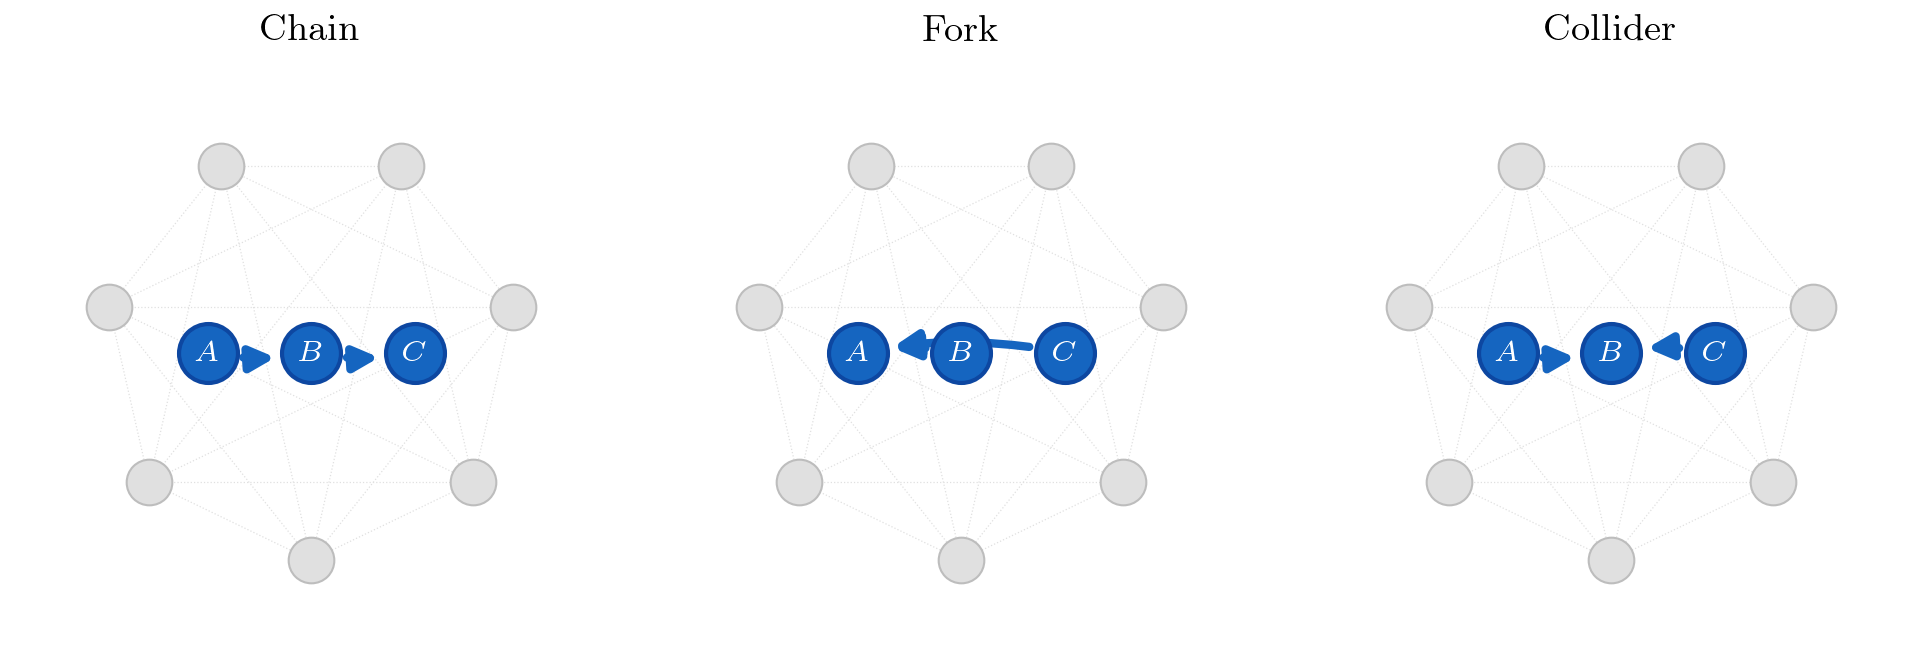

In [58]:
vis = refresh_vis()
fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.2), constrained_layout=True)
for ax, motif in zip(axes, ["Chain", "Fork", "Collider"]):
    vis.plot_motif_graph(motif, M=10, ax=ax)
plt.show()


## `plot_time_series`

Plot a multivariate time-series slice from a real example.

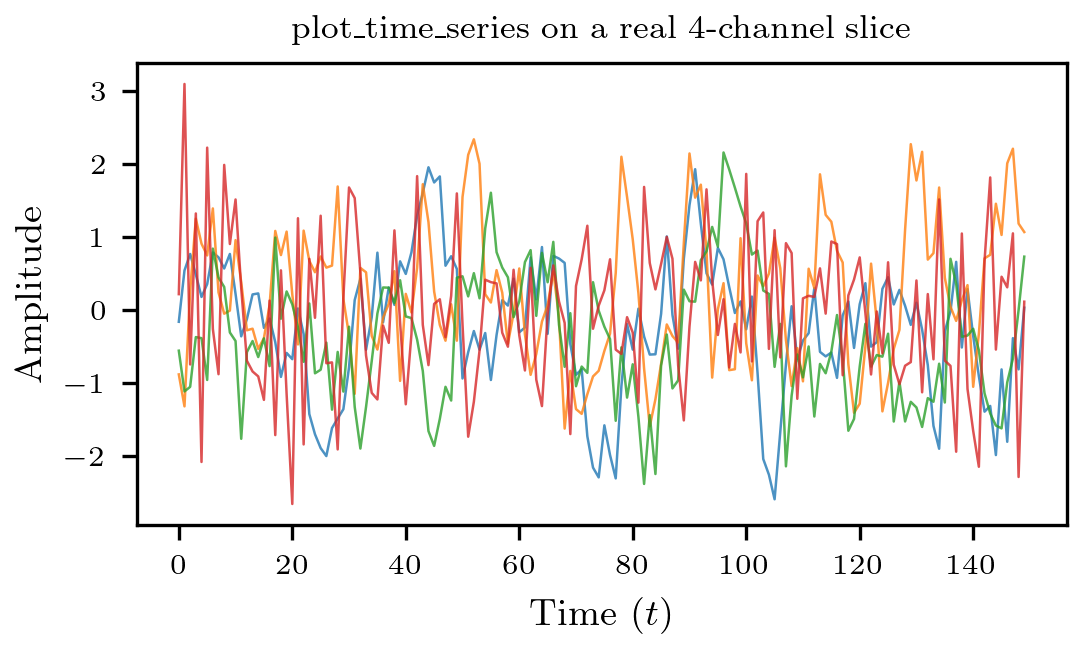

In [59]:
vis = refresh_vis()
ts = np.load(TS_PATH)[:, :4]
fig, ax = vis.plot_time_series(
    ts,
    max_T=150,
    title="plot_time_series on a real 4-channel slice",
    alpha=0.8,
)
plt.show()


## `plot_mts_heatmap`

Render the carpet plot directly from a `.npy` path.

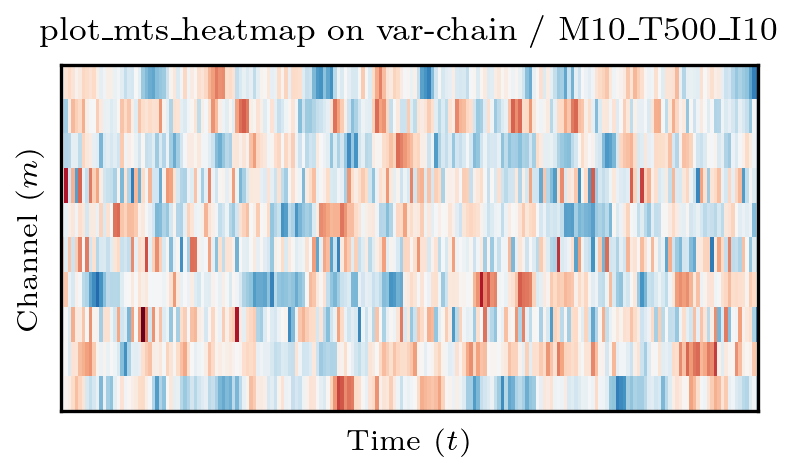

In [60]:
vis = refresh_vis()
fig, ax = vis.plot_mts_heatmap(
    TS_PATH,
    title="plot_mts_heatmap on var-chain / M10_T500_I10",
    max_T=200,
)
plt.show()


## `plot_mpi_heatmap`

Show one symmetric and one directed SPI matrix.

plot_spi_heatmap is an alias: True


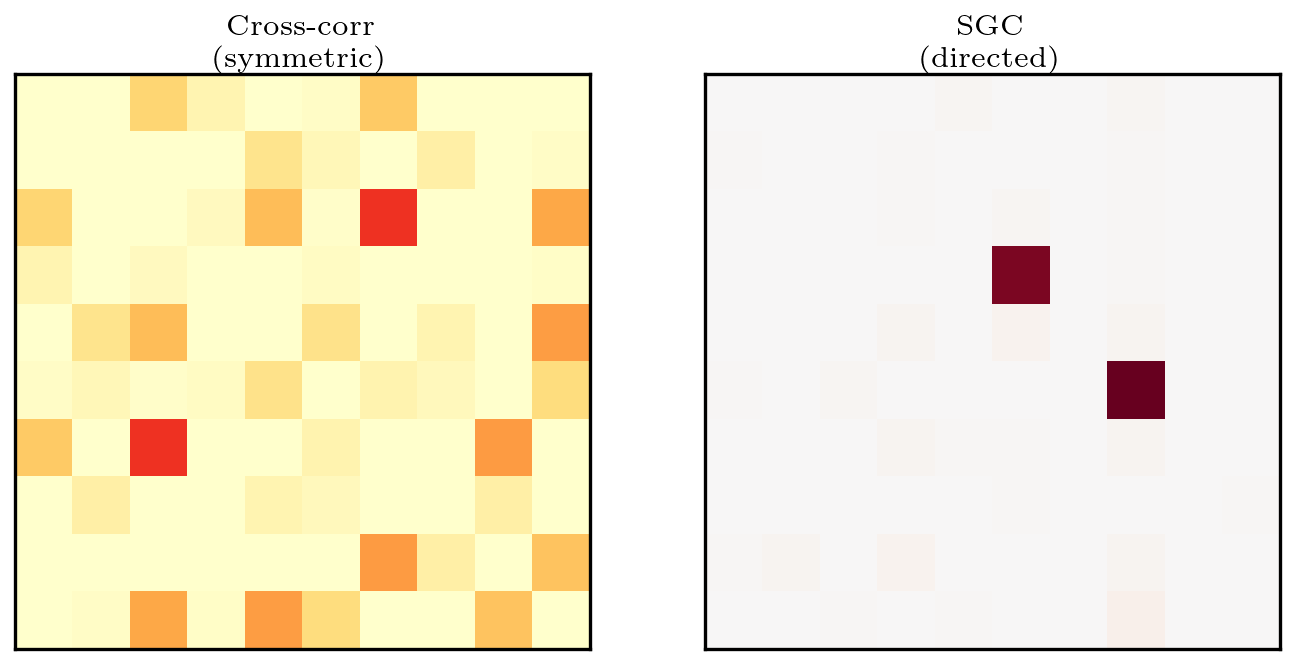

In [61]:
vis = refresh_vis()
fig, axes = plt.subplots(1, 2, figsize=(4.6, 2.2), constrained_layout=True)
vis.plot_mpi_heatmap(
    NPZ_PATH,
    "xcorr_mean_sig-True",
    ax=axes[0],
    title="Cross-corr",
)
vis.plot_mpi_heatmap(
    NPZ_PATH,
    "sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_order-1",
    ax=axes[1],
    title="SGC",
)
print("plot_spi_heatmap is an alias:", vis.plot_spi_heatmap is vis.plot_mpi_heatmap)
plt.show()


## `load_results`

Load the main results JSON and inspect the available keys.

In [62]:
vis = refresh_vis()
results = vis.load_results(RESULTS_MAIN)
print("Classes:", results["classes"])
print("n values:", sorted(results["results"].keys(), key=int))
print("Models at n=500:", sorted(results["results"]["500"]["models"].keys()))


Classes: ['var-chain', 'var-fork', 'var-collider']
n values: ['20', '50', '100', '200', '500', '1000']
Models at n=500: ['correlation', 'fixed-spi', 'latent', 'mlp-mix', 'node-only', 'shuffled', 'spi-mpnn']


## `overlay_model`

Start from the main curve plot, then add edge-ablation from another file.

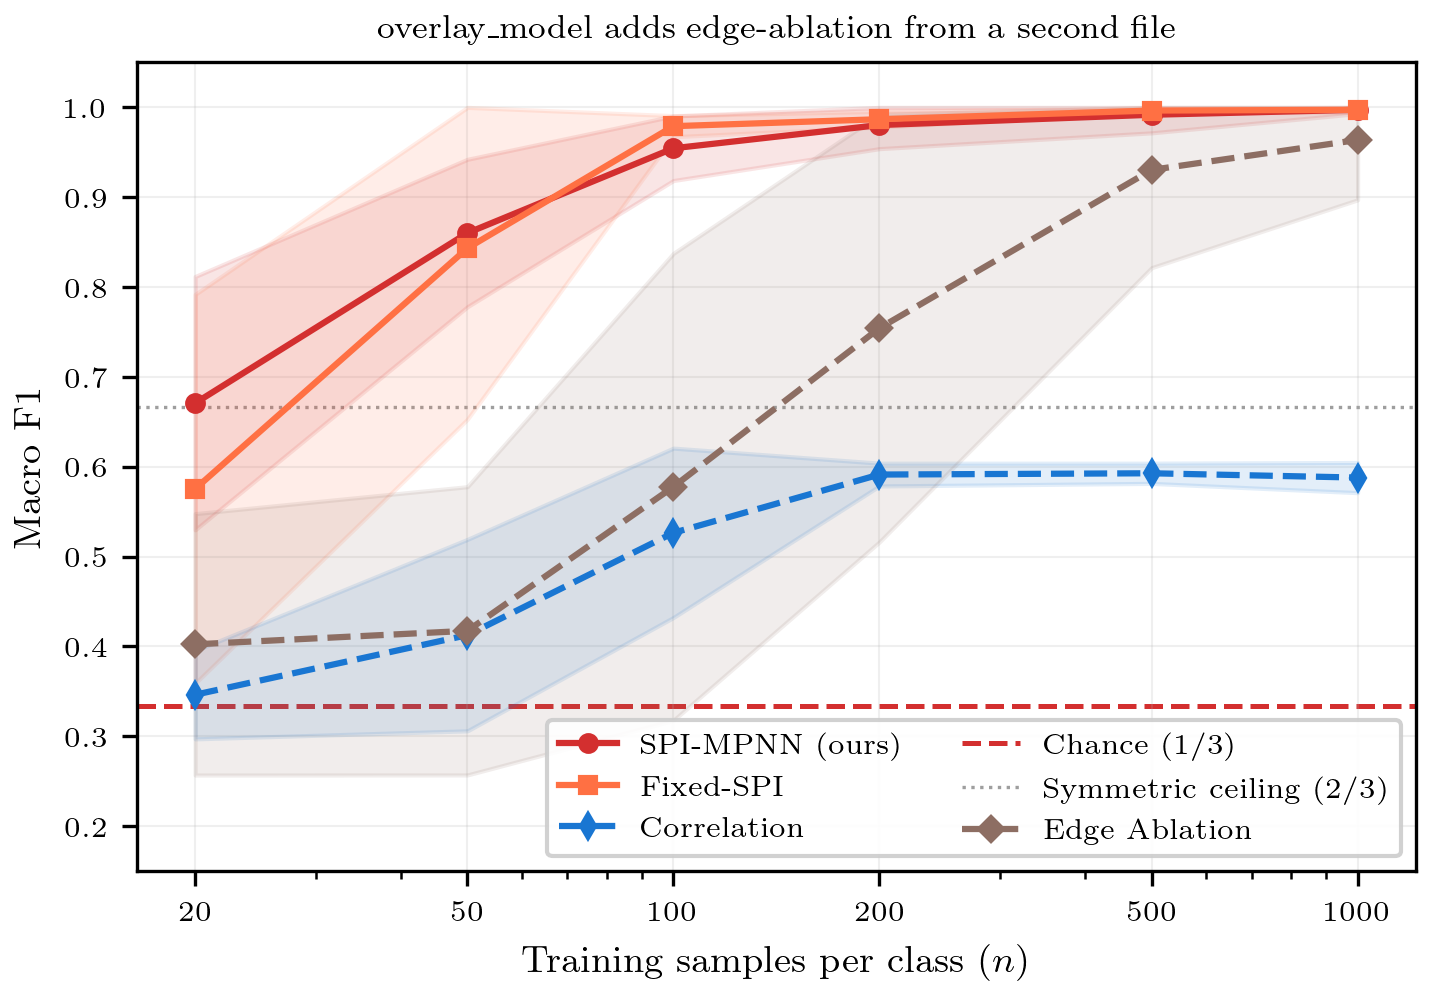

In [63]:
vis = refresh_vis()
fig, ax = vis.plot_sample_efficiency(
    RESULTS_MAIN,
    models=["spi-mpnn", "fixed-spi", "correlation"],
)
vis.overlay_model(ax, RESULTS_EDGE, "edge-ablation")
ax.legend(loc="lower right", framealpha=0.9, ncol=2)
ax.set_title("overlay_model adds edge-ablation from a second file", fontsize=8)
plt.show()


## `plot_sample_efficiency`

Plot the full sample-efficiency panel from one results file.

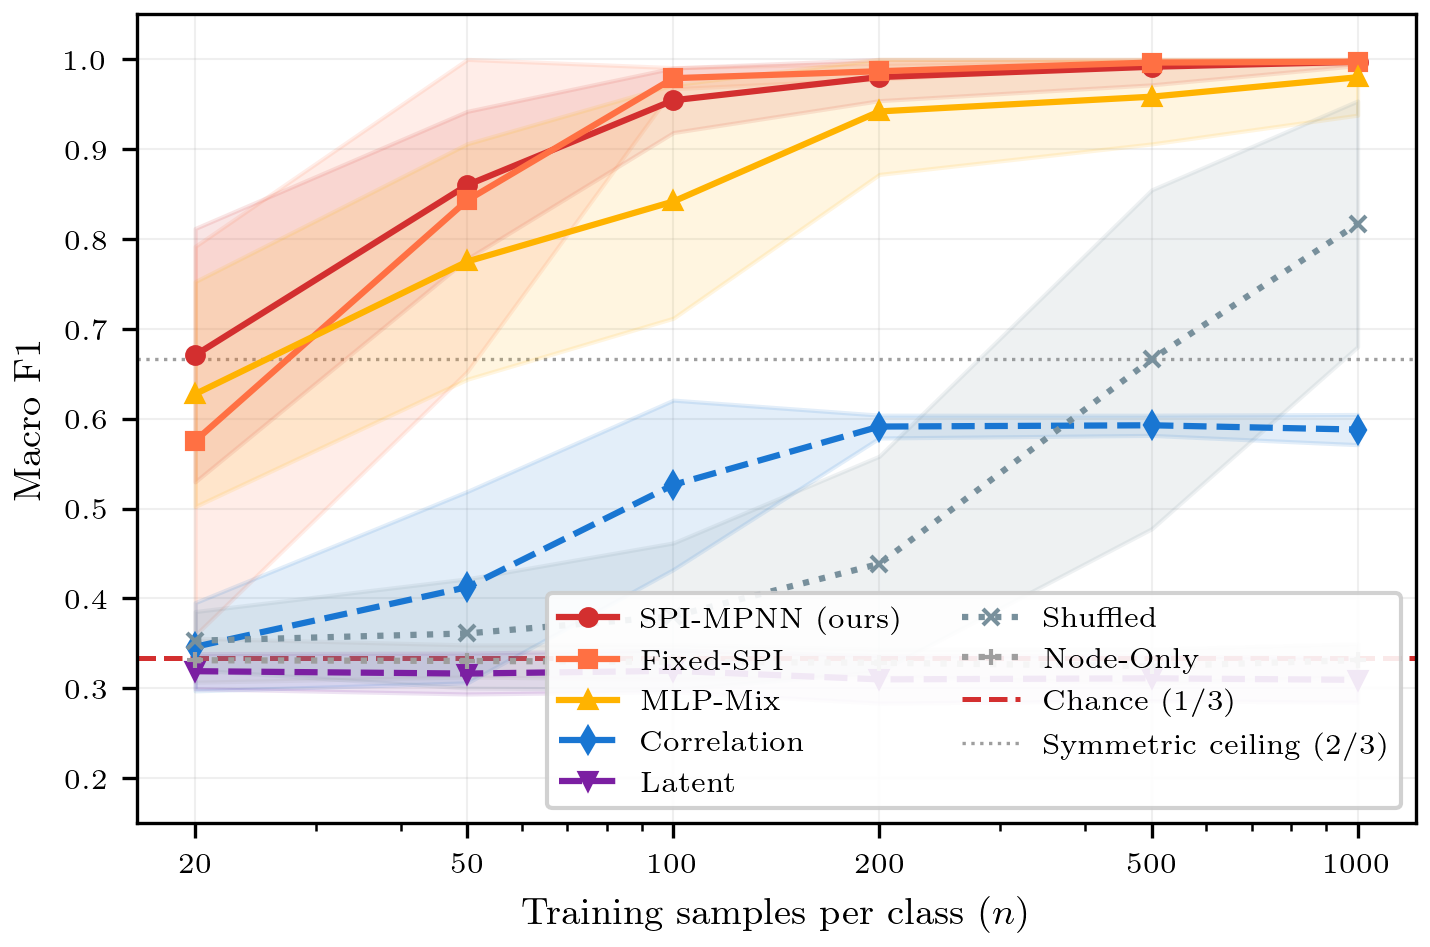

In [64]:
vis = refresh_vis()
fig, ax = vis.plot_sample_efficiency(
    RESULTS_MAIN,
    models=["spi-mpnn", "fixed-spi", "mlp-mix", "correlation", "latent", "shuffled", "node-only"],
    band_mode="std",
)
plt.show()


## `plot_sample_efficiency_multi`

Overlay selected models while sourcing them from different JSON files.

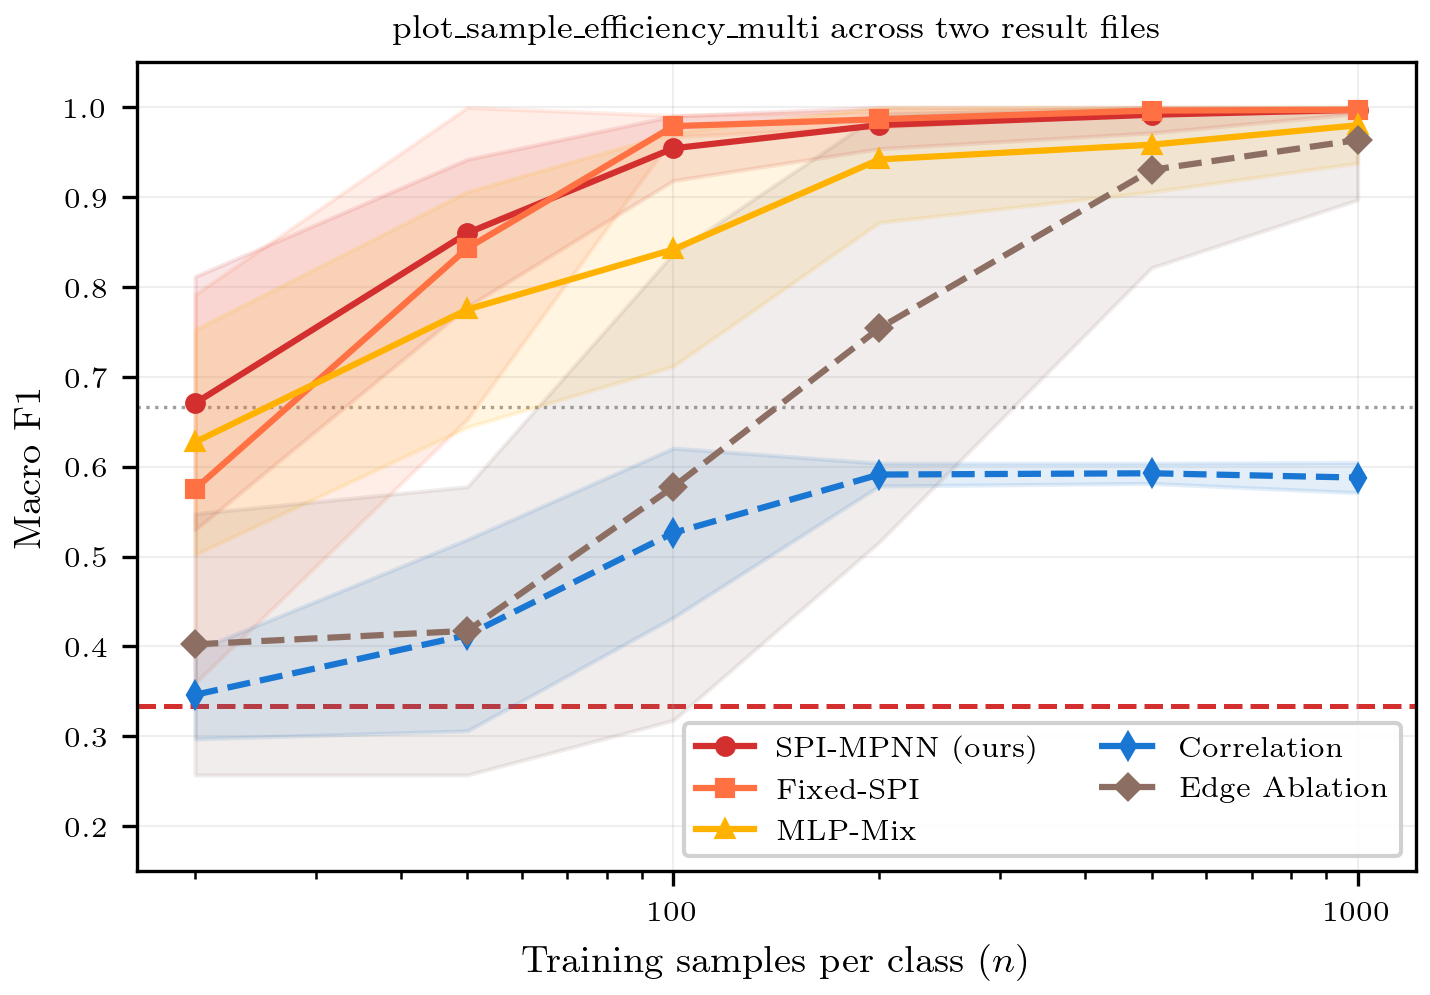

In [65]:
vis = refresh_vis()
results_paths = {
    "spi-mpnn": RESULTS_MAIN,
    "fixed-spi": RESULTS_MAIN,
    "mlp-mix": RESULTS_MAIN,
    "correlation": RESULTS_MAIN,
    "edge-ablation": RESULTS_EDGE,
}
fig, ax = vis.plot_sample_efficiency_multi(results_paths, models=list(results_paths))
ax.set_title("plot_sample_efficiency_multi across two result files", fontsize=8)
plt.show()


## `plot_family_weights`

Visualize the learned weight distribution by SPI family.

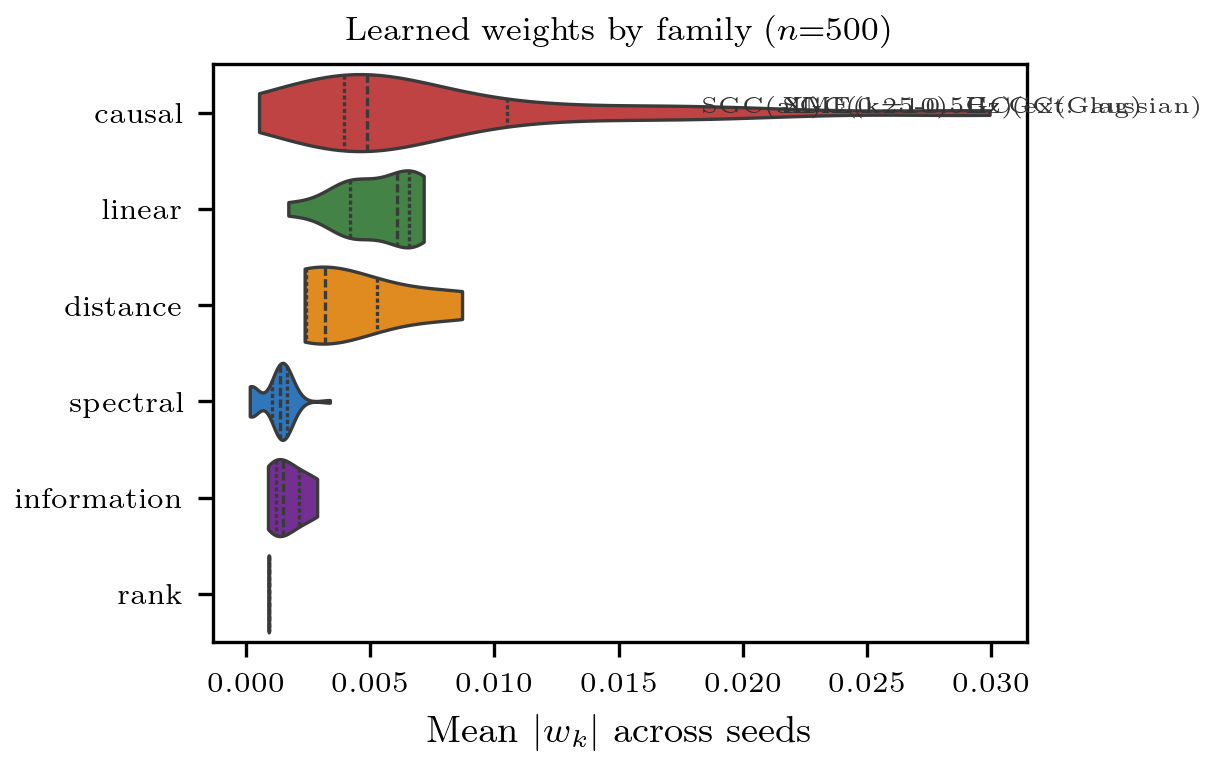

In [66]:
vis = refresh_vis()
fig, ax = vis.plot_family_weights(RESULTS_MAIN, n_value=500, top_k_labels=5)
plt.show()


## `plot_family_bar`

Plot the family-level L2 signature bar chart.

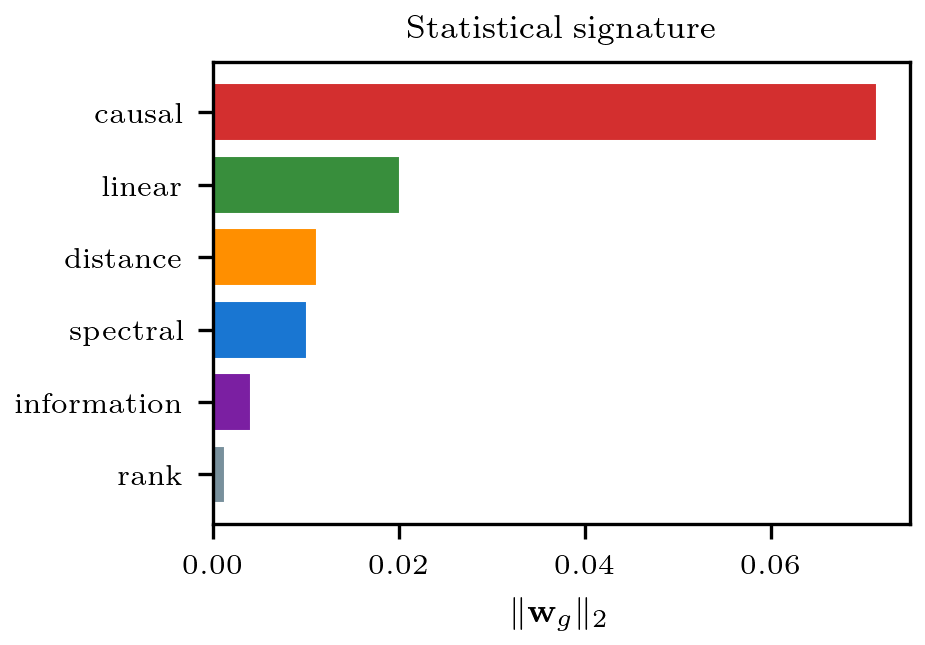

In [67]:
vis = refresh_vis()
fig, ax = vis.plot_family_bar(RESULTS_MAIN, n_value=500)
plt.show()


## `plot_per_seed_strip`

Inspect per-seed spread at one training-set size.

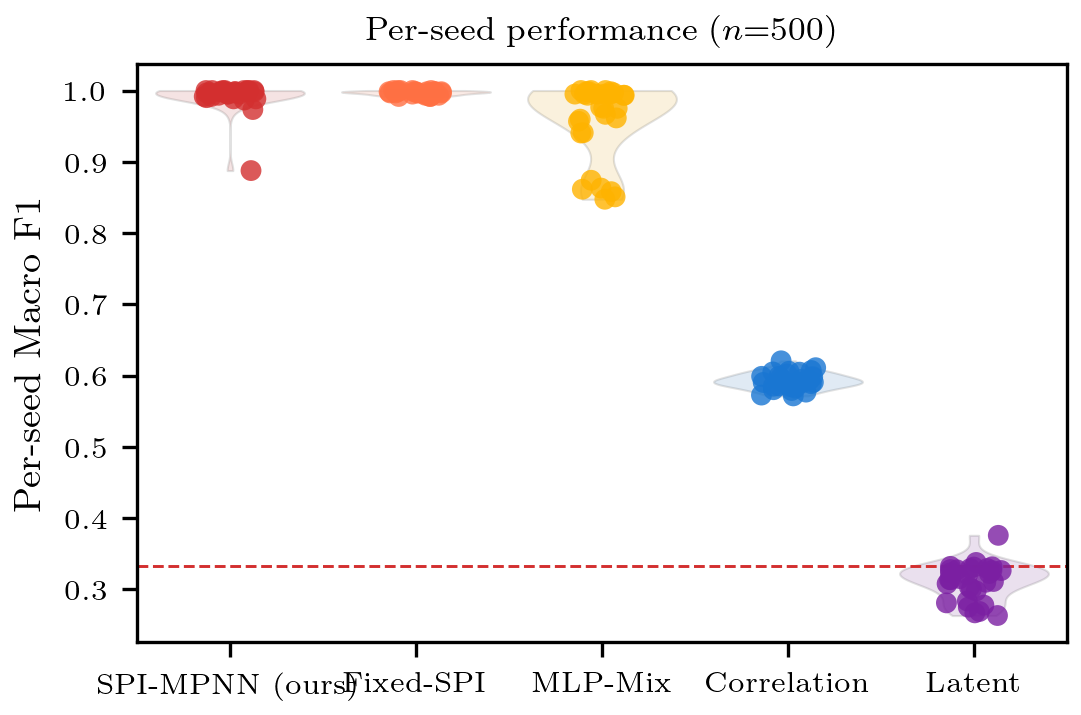

In [68]:
vis = refresh_vis()
fig, ax = vis.plot_per_seed_strip(
    RESULTS_MAIN,
    n_value=500,
    models=["spi-mpnn", "fixed-spi", "mlp-mix", "correlation", "latent"],
    show_violin=True,
)
plt.show()


## `_short_spi_name`

Show how long SPI identifiers are shortened for annotations.

In [69]:
vis = refresh_vis()
for name in [
    "sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_order-1",
    "gc_gaussian_k-1_kt-1_l-1_lt-1",
    "xcorr_Pearson",
    "some_extremely_long_spi_name_that_should_be_trimmed_for_annotations",
]:
    print(f"{name} -> {vis._short_spi_name(name)}")


sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_order-1 -> SGC(0.25-0.5Hz)
gc_gaussian_k-1_kt-1_l-1_lt-1 -> GC(Gaussian)
xcorr_Pearson -> Pearson r
some_extremely_long_spi_name_that_should_be_trimmed_for_annotations -> some_extremely_long_sp...


## `main`

Optional: run the CLI-style exporter from inside the notebook.

In [70]:
vis = refresh_vis()
RUN_MAIN_DEMO = False

if RUN_MAIN_DEMO:
    old_argv = sys.argv[:]
    try:
        sys.argv = [
            "visualization.py",
            "--fig2-only",
            "--outdir",
            "figures/notebook_demo",
        ]
        vis.main()
    finally:
        sys.argv = old_argv
else:
    print("Set RUN_MAIN_DEMO = True if you want to run visualization.main() from the notebook.")


Set RUN_MAIN_DEMO = True if you want to run visualization.main() from the notebook.
